<a href="https://colab.research.google.com/github/tanvi257/nifty50-investment-intelligence/blob/main/nifty50_exploration_and_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NIFTY-50 Investment Intelligence: Exploration & Model Training

1. **Data Loading & Cleaning**: Accessing raw stock prices and metadata.
2. **Exploratory Data Analysis (EDA)**: Visualizing distributions, correlations, and price trajectories.
3. **Feature Engineering**: Computing technical indicators (RSI, MACD, Bollinger Bands, Volatility, Momentum).
4. **Model Training & Validation**: Training and evaluating Machine Learning models for return forecasting and direction prediction.
5. **Portfolio Construction**: Running Mean-Variance Optimization (MVO) for Conservative, Balanced, and Aggressive profiles.
6. **Explainability & Anomaly Detection**: Feature importance analysis and identifying market anomalies.

## 1. Setup and Environment

In [1]:
!unzip nifty50_investment_intelligence.zip

Archive:  nifty50_investment_intelligence.zip
   creating: .git/
   creating: data/
   creating: models/
   creating: src/
  inflating: .gitignore              
  inflating: app.py                  
  inflating: nifty50_exploration_and_training.ipynb  
  inflating: README.md               
  inflating: requirements.txt        
   creating: .git/hooks/
   creating: .git/info/
   creating: .git/logs/
   creating: .git/objects/
   creating: .git/refs/
  inflating: .git/COMMIT_EDITMSG     
  inflating: .git/config             
  inflating: .git/description        
  inflating: .git/HEAD               
  inflating: .git/index              
  inflating: .git/hooks/applypatch-msg.sample  
  inflating: .git/hooks/commit-msg.sample  
  inflating: .git/hooks/fsmonitor-watchman.sample  
  inflating: .git/hooks/post-update.sample  
  inflating: .git/hooks/pre-applypatch.sample  
  inflating: .git/hooks/pre-commit.sample  
  inflating: .git/hooks/pre-merge-commit.sample  
  inflating: .git/hooks/pr

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from src.data_loader import NiftyDataLoader
from src.features import compute_technical_indicators, generate_predictor_features
from src.predictor import StockPredictorEngine
from src.portfolio import PortfolioConstructor
from src.risk import RiskAssessor
from src.anomaly import MarketAnomalyDetector
from src.explainability import ExplainabilityEngine

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print("Libraries successfully imported!")

Libraries successfully imported!


## 2. Data Loading & Cleaning
loading the stock metadata and historical daily prices using `NiftyDataLoader`. If no files exist in the `data/` directory it automatically generates a realistic synthetic dataset for you.

In [3]:
loader = NiftyDataLoader()
metadata = loader.load_metadata()
print("Stock Metadata:")
display(metadata)

stock_data = loader.load_all_stocks()
print(f"\nSuccessfully loaded data for {len(stock_data)} stocks.")

Stock Metadata:


,Company Name,Industry,Symbol,Series,ISIN Code,Sector
0,Adani Ports and Special Economic Zone Ltd.,SERVICES,ADANIPORTS,EQ,INE742F01042,SERVICES
1,Asian Paints Ltd.,CONSUMER GOODS,ASIANPAINT,EQ,INE021A01026,CONSUMER GOODS
2,Axis Bank Ltd.,FINANCIAL SERVICES,AXISBANK,EQ,INE238A01034,FINANCIAL SERVICES
3,Bajaj Auto Ltd.,AUTOMOBILE,BAJAJ-AUTO,EQ,INE917I01010,AUTOMOBILE
4,Bajaj Finserv Ltd.,FINANCIAL SERVICES,BAJAJFINSV,EQ,INE918I01018,FINANCIAL SERVICES
5,Bajaj Finance Ltd.,FINANCIAL SERVICES,BAJFINANCE,EQ,INE296A01024,FINANCIAL SERVICES
6,Bharti Airtel Ltd.,TELECOM,BHARTIARTL,EQ,INE397D01024,TELECOM
7,Bharat Petroleum Corporation Ltd.,ENERGY,BPCL,EQ,INE029A01011,ENERGY
8,Britannia Industries Ltd.,CONSUMER GOODS,BRITANNIA,EQ,INE216A01030,CONSUMER GOODS
9,Cipla Ltd.,PHARMA,CIPLA,EQ,INE059A01026,PHARMA


File M&M.csv not found. Loading from NIFTY50_all.csv...

Successfully loaded data for 49 stocks.


## 3. Exploratory Data Analysis (EDA)
Price chart of a selected stock (e.g. HDFCBANK) and plot the correlation/covariance heatmap of returns.

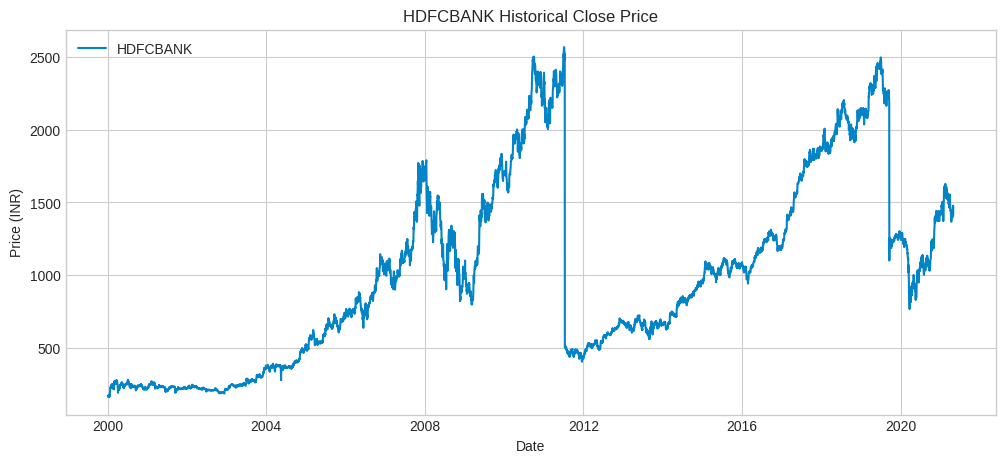

In [4]:
symbol = "HDFCBANK"
df_stock = stock_data[symbol]

plt.figure(figsize=(12, 5))
plt.plot(df_stock['Date'], df_stock['Close'], label=symbol, color='#0284c7')
plt.title(f"{symbol} Historical Close Price")
plt.xlabel("Date")
plt.ylabel("Price (INR)")
plt.legend()
plt.show()

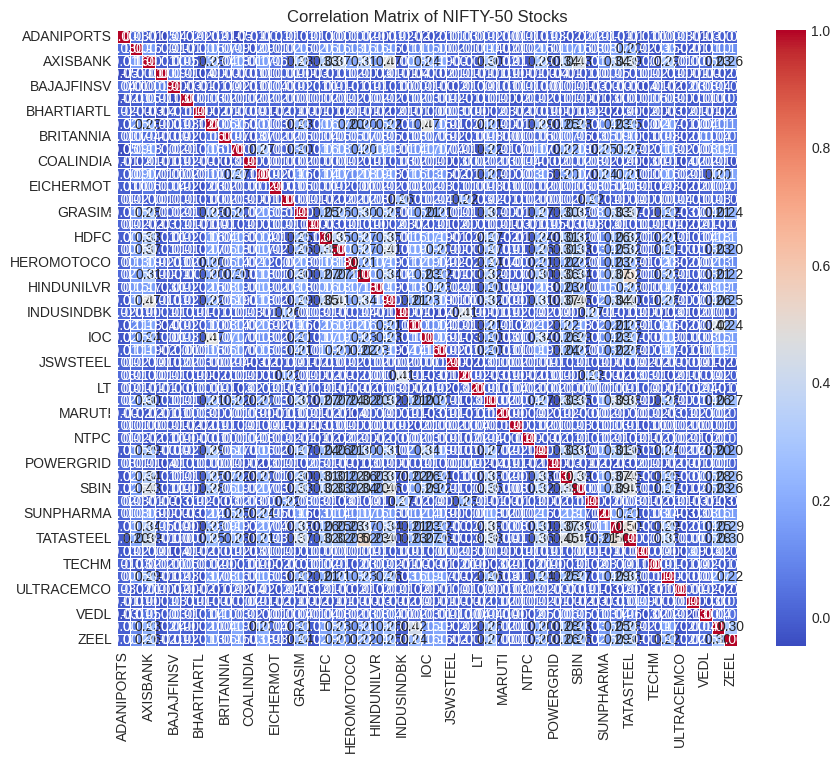

In [5]:
# Calculate returns and show the correlation matrix
returns_dict = {}
for sym, df in stock_data.items():
    returns_dict[sym] = df['Close'].pct_change().fillna(0)
returns_df = pd.DataFrame(returns_dict)

plt.figure(figsize=(10, 8))
sns.heatmap(returns_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of NIFTY-50 Stocks")
plt.show()

## 4. Feature Engineering
computing technical indicators such as RSI, MACD, and Bollinger Bands using our vectorized operations in `src/features.py`.

In [6]:
df_indicators = compute_technical_indicators(df_stock)
print(f"Generated indicators for {symbol}. First 5 rows:")
display(df_indicators[['Date', 'Close', 'SMA_50', 'RSI_14', 'MACD', 'BB_Upper', 'BB_Lower']].head())

Generated indicators for HDFCBANK. First 5 rows:


,Date,Close,SMA_50,RSI_14,MACD,BB_Upper,BB_Lower
0,2000-01-03,170.00,170.0000,50.000000,0.000000,170.000000,170.000000
1,2000-01-04,173.80,171.9000,100.000000,0.303134,177.274012,166.525988
2,2000-01-05,166.95,170.2500,35.680751,-0.009261,177.113672,163.386328
3,2000-01-06,168.30,169.7625,42.916667,-0.146218,175.696231,163.828769
4,2000-01-07,168.35,169.4800,43.153527,-0.247864,174.771786,164.188214


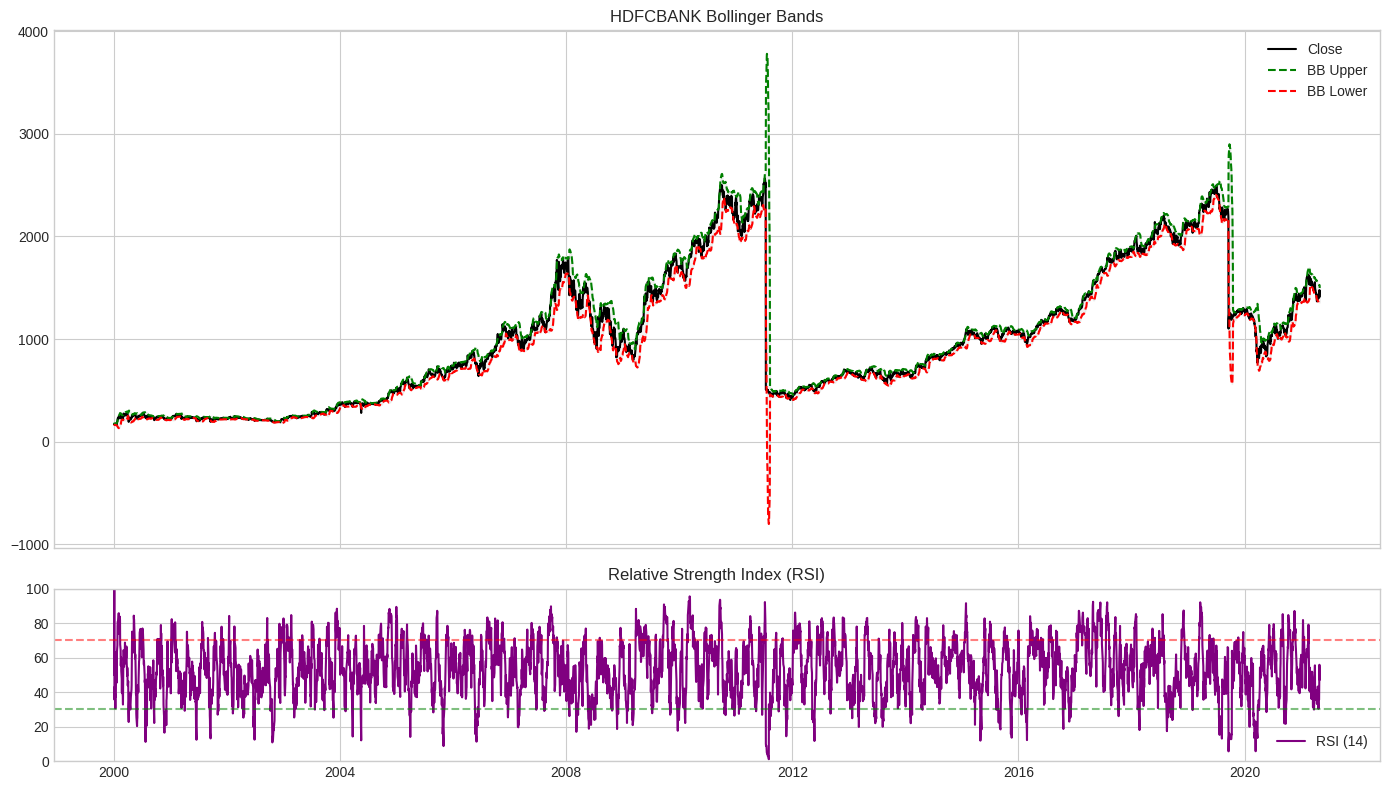

In [7]:
# Plot Bollinger Bands & RSI
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

ax1.plot(df_indicators['Date'], df_indicators['Close'], label='Close', color='black')
ax1.plot(df_indicators['Date'], df_indicators['BB_Upper'], label='BB Upper', color='green', linestyle='--')
ax1.plot(df_indicators['Date'], df_indicators['BB_Lower'], label='BB Lower', color='red', linestyle='--')
ax1.fill_between(df_indicators['Date'], df_indicators['BB_Lower'], df_indicators['BB_Upper'], color='gray', alpha=0.1)
ax1.set_title(f"{symbol} Bollinger Bands")
ax1.legend()

ax2.plot(df_indicators['Date'], df_indicators['RSI_14'], label='RSI (14)', color='purple')
ax2.axhline(70, color='red', linestyle='--', alpha=0.5)
ax2.axhline(30, color='green', linestyle='--', alpha=0.5)
ax2.set_title("Relative Strength Index (RSI)")
ax2.set_ylim(0, 100)
ax2.legend()

plt.tight_layout()
plt.show()

## 5. Model Training and Predictions
training models to forecast the 5-day forward return (regression) and direction (classification) using the `StockPredictorEngine`.

In [8]:
predictor_engine = StockPredictorEngine()
reg_metrics, clf_metrics = predictor_engine.train_models(df_stock, symbol)

print("Regressor Metrics:")
for k, v in reg_metrics.items():
    print(f"  {k}: {v:.6f}")

print("\nClassifier Metrics:")
for k, v in clf_metrics.items():
    print(f"  {k}: {v:.4f}")

Regressor Metrics:
  MAE: 0.031361
  RMSE: 0.054292
  R2: -0.334497

Classifier Metrics:
  Accuracy: 0.4929
  F1_Score: 0.5906


In [9]:
# Generate future predictions on latest data
predictions = predictor_engine.predict(df_stock, symbol)
print(f"Predictions for {symbol} on {predictions['Date']}:")
for k, v in predictions.items():
    print(f"  {k}: {v}")

Predictions for HDFCBANK on 2021-04-30T00:00:00.000000000:
  Symbol: HDFCBANK
  Date: 2021-04-30T00:00:00.000000000
  Current_Close: 1412.3
  Predicted_5d_Return: 0.011209835690426967
  Predicted_Direction: UP
  Direction_Probability: 0.555789741141138


## 6. Portfolio Construction & Optimization
Portfolios for different risk tolerances using the `PortfolioConstructor` class, applying Mean-Variance Optimization (MVO).

In [13]:
risk_free_rate = 0.0675
p_constructor = PortfolioConstructor(stock_data, metadata)

for profile in ["Conservative", "Balanced", "Aggressive"]:
    p = p_constructor.construct_portfolio(profile, risk_free_rate=risk_free_rate)
    print("=" * 60)
    print(f"PROFILE: {profile}")
    print(f"  Expected Return: {p['Expected_Annualized_Return']*100:.2f}%")
    print(f"  Volatility: {p['Expected_Annualized_Volatility']*100:.2f}%")
    print(f"  Sharpe Ratio: {p['Sharpe_Ratio']:.4f}")
    print("  Top Holdings:")
    display(p["Allocations"].head(3))
    print(f"  Justification: {p['Justification']}\n")

PROFILE: Conservative
  Expected Return: 17.33%
  Volatility: 7.57%
  Sharpe Ratio: 1.3985
  Top Holdings:


,Symbol,Company Name,Sector,Weight
27,NESTLEIND,Nestle India Ltd.,CONSUMER GOODS,0.092567
29,POWERGRID,Power Grid Corporation of India Ltd.,ENERGY,0.065930
9,COALINDIA,Coal India Ltd.,METALS,0.062397


  Justification: Recommended for capital preservation. The algorithm uses Markowitz Mean-Variance Optimization to minimize portfolio variance. Individual stock allocations are capped at 40% to ensure high diversification, skewing heavily towards historically low-beta, low-volatility sectors (e.g. Consumer Goods, Pharmaceuticals).

PROFILE: Balanced
  Expected Return: 25.88%
  Volatility: 9.60%
  Sharpe Ratio: 1.9932
  Top Holdings:


,Symbol,Company Name,Sector,Weight
19,NESTLEIND,Nestle India Ltd.,CONSUMER GOODS,0.104593
21,SHREECEM,Shree Cement Ltd.,CEMENT & CEMENT PRODUCTS,0.091599
18,MARUTI,Maruti Suzuki India Ltd.,AUTOMOBILE,0.083916


  Justification: Recommended for investors seeking a balance of growth and stability. The optimization maximizes the Sharpe Ratio, aligning allocation with the highest risk-adjusted performance. Weights are capped at 35% to maintain strong diversification across Banking, Energy, and Information Technology.

PROFILE: Aggressive
  Expected Return: 37.23%
  Volatility: 25.09%
  Sharpe Ratio: 1.2147
  Top Holdings:


,Symbol,Company Name,Sector,Weight
1,BAJFINANCE,Bajaj Finance Ltd.,FINANCIAL SERVICES,0.4
3,SHREECEM,Shree Cement Ltd.,CEMENT & CEMENT PRODUCTS,0.3
2,EICHERMOT,Eicher Motors Ltd.,AUTOMOBILE,0.2


  Justification: Recommended for investors targeting maximum capital appreciation. The portfolio concentrates capital into the top 4 assets with the highest predicted forward returns (regression output) or strongest price momentum. This concentrates returns, sacrificing short-term stability for maximum upside.



## 7. Explainable AI & Anomaly Detection
Permutation importance of features in our models and check for recent anomalies.

/tmp/ipykernel_4519/3985078242.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(10), x="Importance_Mean", y="Feature", palette="viridis")


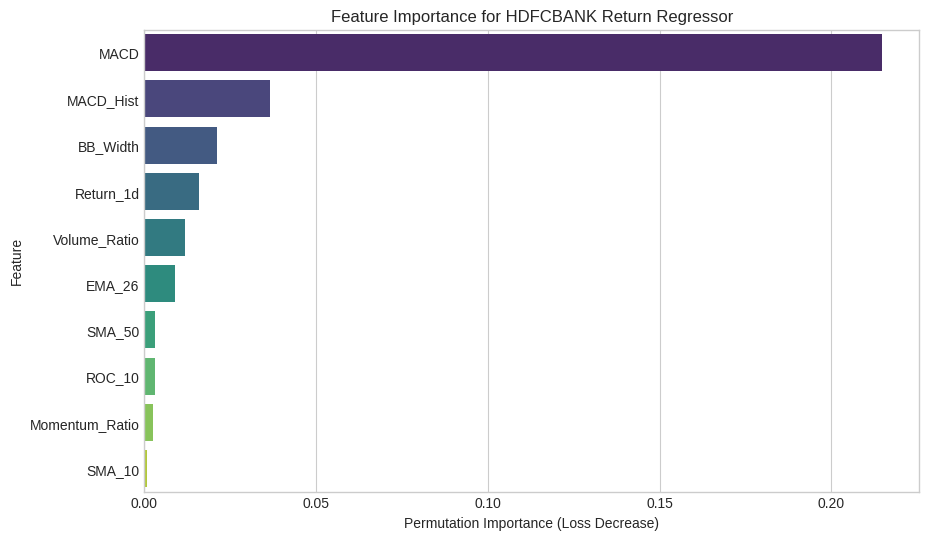

In [11]:
reg_model, feat_cols, _ = predictor_engine.load_model(symbol, "regressor")
explainer = ExplainabilityEngine()
importance_df = explainer.compute_model_feature_importance(reg_model, df_stock, feat_cols)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(10), x="Importance_Mean", y="Feature", palette="viridis")
plt.title(f"Feature Importance for {symbol} Return Regressor")
plt.xlabel("Permutation Importance (Loss Decrease)")
plt.ylabel("Feature")
plt.show()

In [12]:
# Detect market anomalies in HDFCBANK
detector = MarketAnomalyDetector()
anomalies = detector.detect_anomalies(df_stock)
print(f"Total anomalies detected in {symbol}: {len(anomalies)}")
if not anomalies.empty:
    display(anomalies.head(10))

Total anomalies detected in HDFCBANK: 255


,Date,Symbol,Type,Metric,Details,Severity
0,2021-04-30,HDFCBANK,Extreme Drawdown,Daily Drop: -4.09%,Daily price decline fell below the critical ri...,Medium
1,2021-04-12,HDFCBANK,Extreme Drawdown,Daily Drop: -3.85%,Daily price decline fell below the critical ri...,Medium
2,2021-03-31,HDFCBANK,Extreme Drawdown,Daily Drop: -3.86%,Daily price decline fell below the critical ri...,Medium
3,2021-02-26,HDFCBANK,Extreme Drawdown,Daily Drop: -4.48%,Daily price decline fell below the critical ri...,Medium
4,2021-01-27,HDFCBANK,Extreme Drawdown,Daily Drop: -3.64%,Daily price decline fell below the critical ri...,Medium
5,2020-07-27,HDFCBANK,Extreme Drawdown,Daily Drop: -3.54%,Daily price decline fell below the critical ri...,Medium
6,2020-05-18,HDFCBANK,Extreme Drawdown,Daily Drop: -5.80%,Daily price decline fell below the critical ri...,High
7,2020-05-14,HDFCBANK,Extreme Drawdown,Daily Drop: -3.66%,Daily price decline fell below the critical ri...,Medium
8,2020-05-04,HDFCBANK,Extreme Drawdown,Daily Drop: -7.87%,Daily price decline fell below the critical ri...,High
9,2020-04-15,HDFCBANK,Extreme Drawdown,Daily Drop: -3.58%,Daily price decline fell below the critical ri...,Medium
